In [2]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from fenics import UnitSquareMesh, FunctionSpace

from utils.colors import C5, M, MS
from utils.utils import progress_bar, disk_cache
from utils.plotting import save_plot

from algorithms.rsvd_solvers_timed import MatrixFreeRSVDTimed

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 14,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})


In [3]:
@disk_cache("../../results/computational_breakdown_new")
def experiment1(k_range: np.ndarray, N: int, repeat: int = 1):
    n_k = len(k_range)
    n = round(np.sqrt(N))
    mesh = UnitSquareMesh(n, n)
    V_h = FunctionSpace(mesh, 'CG', 1)

    # (repeat, k_range, 5 time points)
    times = np.zeros((repeat, n_k, 5))

    step = 1
    n_steps = len(k_range) * repeat
    for r in range(repeat):
        for i, k in enumerate(k_range):
            rsvd = MatrixFreeRSVDTimed(V_h)
            rsvd.solve(k)
            times[r, i, :] = rsvd.times

            progress_bar(step, n_steps, end_text=f' [{r=}, {k=}]')
            step += 1
    return times


In [4]:
k_range = np.arange(5, 250, 20)

params1 = [
    {'k_range': k_range, 'N': 4_000, 'repeat': 3},  # ORIGINAL: 30, 30, 10
    {'k_range': k_range, 'N': 40_000, 'repeat': 3},
    {'k_range': k_range, 'N': 400_000, 'repeat': 1}
]

results = {p['N']: experiment1(**p) for p in params1}
medians = {N: np.median(arr, axis=0) for N, arr in results.items()}

[##############################] 39/39 [r=2, k=245]
[##############################] 39/39 [r=2, k=245]
[##############################] 13/13 [r=0, k=245]


../../figures/rsvd_computational_breakdown.png already exists


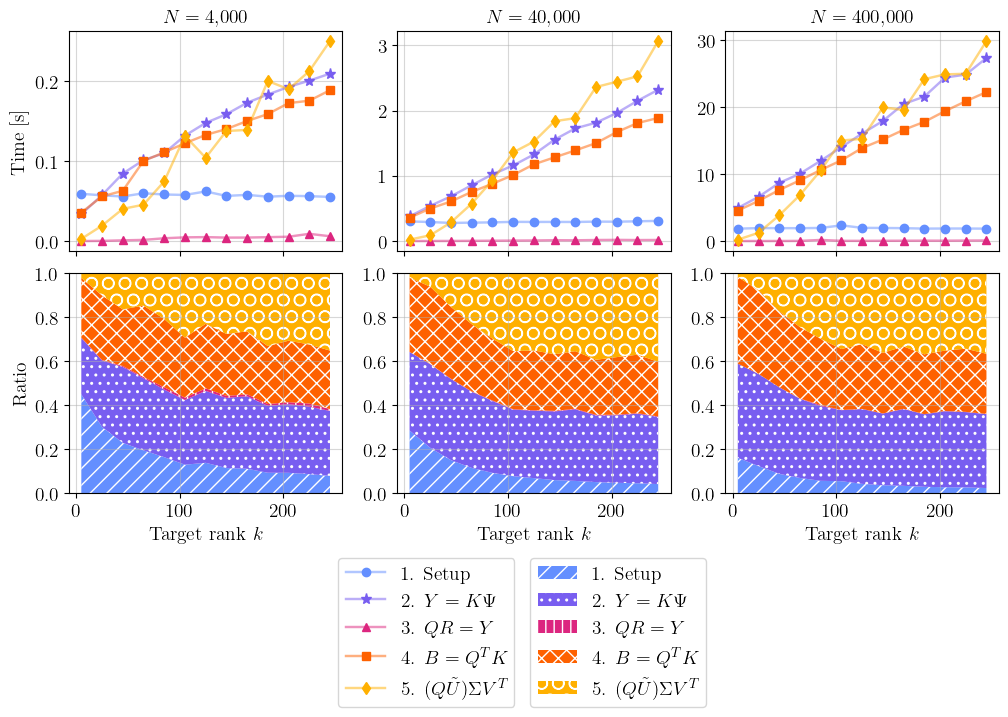

In [5]:
def plot_times_across_k(medians, k_range, fig_name=None):
    fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
    s = 1

    labels = [
        '1. Setup',
        '2. $Y = K \Psi$',
        '3. $QR = Y$',
        '4. $B = Q^T K$',
        '5. $(Q \\tilde U) \Sigma V^T$'
    ]

    for i, median in enumerate(medians.values()):
        ax1, ax2 = axes[:, i]

        tot = np.sum(median, axis=1)
        rel = median / tot[:, np.newaxis]

        # Line plots
        for i in range(5):
            ax1.plot(k_range[::s], median[:, i][::s], M[i], ms=MS[i], c=C5[i])
            ax1.plot(k_range, median[:, i], c=C5[i], lw=1.75, alpha=0.5)

        # Stack plots
        polys = ax2.stackplot(
            k_range,
            rel[:, 0], rel[:, 1], rel[:, 2], rel[:, 3], rel[:, 4],
            labels=labels,
            alpha=1.0,
            colors=C5,
            hatch=['//', '..', '||', 'xx', 'O']
        )

        # Hatch colors for stack plots
        for poly in polys:
            poly.set_edgecolor('white')
            poly.set_linewidth(0)  # prevents visible polygon border

        ax2.set_xlabel('Target rank $k$')
        ax2.set_ylim(0, 1)

    for ax in axes.flatten():
        ax.grid(True, alpha=0.5)

    # Custom labels
    handles, labs = [], []
    for i in range(5):
        legend_line = Line2D([0], [0], color=C5[i], linewidth=1.75, alpha=0.5)
        legend_marker = Line2D([0], [0], color=C5[i], marker=M[i], markersize=MS[i], linestyle='None')
        handles.append((legend_line, legend_marker))
        labs.append(labels[i])

    axes[0][0].set_title("$N=4{,}000$", fontsize=14)
    axes[0][1].set_title("$N=40{,}000$", fontsize=14)
    axes[0][2].set_title("$N=400{,}000$", fontsize=14)
    axes[0][0].set_ylabel("Time [s]")
    axes[1][0].set_ylabel("Ratio")

    dx = -0.05
    axes[1][1].legend(bbox_to_anchor=(0.5 + dx, -0.25), loc='upper left')  # fill
    axes[0][1].legend(handles=handles, labels=labels,
                      bbox_to_anchor=(-0.2 + dx, -1.35), loc='upper left') # lines
    
    plt.subplots_adjust(wspace=0.20, hspace=0.1)
    save_plot(fig_name)
    plt.show()


plot_times_across_k(medians, k_range, fig_name='rsvd_computational_breakdown')

In [6]:

def print_table(medians, k_range, k_index):
    rel = {}
    for N, median in medians.items():
        tot = np.sum(median, axis=1)
        rel[N] =  median / tot[:, np.newaxis]

    r4   = rel[4_000]
    r40  = rel[40_000]
    r400 = rel[400_000]

    i1, i2 = k_index
    print(f"for k = {k_range[k_index]}:")
    print("4,000       | 40,000      | 400,000")
    print("---------------------------------------")
    print("25   | 105  | 25   | 105  | 25   | 105")
    print("---------------------------------------")
    for stage in range(5):
        x4, y4     = r4[i1, stage], r4[i2, stage]
        x40, y40   = r40[i1, stage], r40[i2, stage]
        x400, y400 = r400[i1, stage], r400[i2, stage]
        t = f"{x4:.2f} & {y4:.2f} & {x40:.2f} & {y40:.2f} & {x400:.2f} & {y400:.2f}"
        print(t)

print_table(medians, k_range, k_index=[1, 5])

for k = [ 25 105]:
4,000       | 40,000      | 400,000
---------------------------------------
25   | 105  | 25   | 105  | 25   | 105
---------------------------------------
0.30 & 0.13 & 0.21 & 0.08 & 0.12 & 0.05
0.30 & 0.29 & 0.38 & 0.30 & 0.42 & 0.32
0.00 & 0.01 & 0.00 & 0.00 & 0.00 & 0.00
0.29 & 0.27 & 0.35 & 0.26 & 0.38 & 0.28
0.10 & 0.29 & 0.06 & 0.35 & 0.08 & 0.35


In [7]:
@disk_cache("../../results/computational_breakdown_new")
def experiment2(N_range: np.ndarray, k: int, repeat: int = 1):
    times = []
    n_n = len(N_range)
    times = np.zeros((repeat, n_n, 5))

    step = 1
    n_steps = n_n * repeat
    for r in range(repeat):
        for i, N in enumerate(N_range):
            n = round(np.sqrt(N))
            mesh = UnitSquareMesh(n, n)
            V_h = FunctionSpace(mesh, 'CG', 1)
            rsvd = MatrixFreeRSVDTimed(V_h)

            rsvd.solve(k)
            times[r, i, :] = rsvd.times
            progress_bar(step, n_steps, end_text=f' [{r=}, N={rsvd.N:,}]')
            step += 1

    return times


In [6]:
N_range = np.linspace(4_000, 400_000, 10)

params2 = [
    {'N_range': N_range, 'k': 10, 'repeat': 30},
    {'N_range': N_range, 'k': 50, 'repeat': 10},
    {'N_range': N_range, 'k': 200, 'repeat': 10}
]

results2 = {p['k']: experiment2(**p) for p in params2}
medians2 = {N: np.median(arr, axis=0) for N, arr in results2.items()}

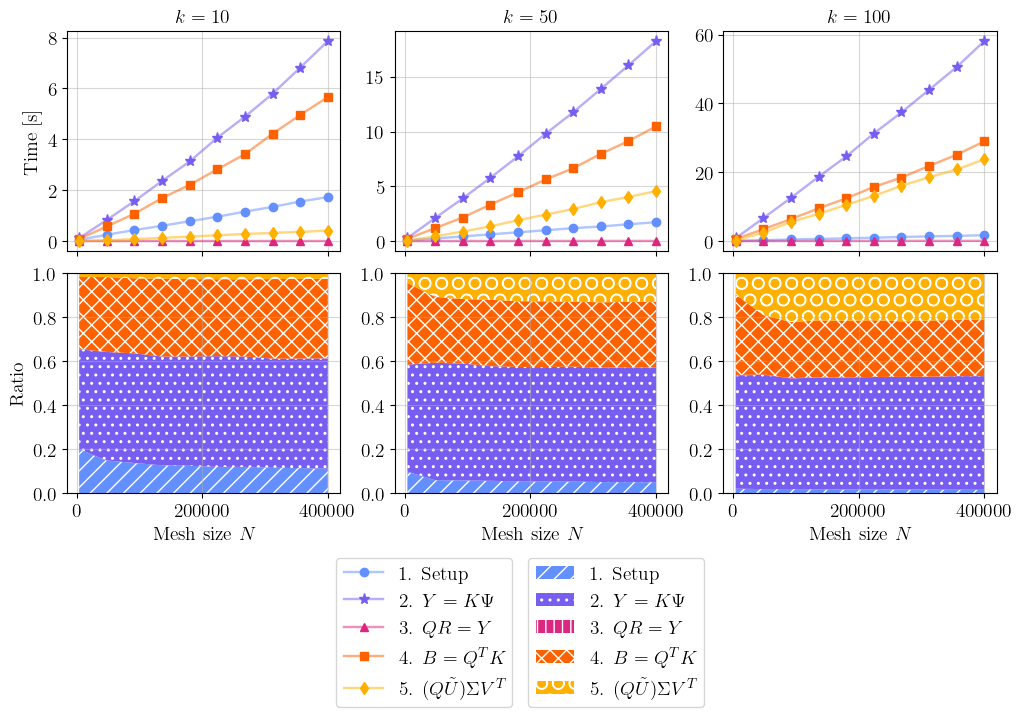

In [7]:
def plot_times_across_N(medians, N_range, fig_name=None):
    fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
    s = 1

    labels = [
        '1. Setup',
        '2. $Y = K \Psi$',
        '3. $QR = Y$',
        '4. $B = Q^T K$',
        '5. $(Q \\tilde U) \Sigma V^T$'
    ]

    for i, median in enumerate(medians.values()):
        ax1, ax2 = axes[:, i]

        tot = np.sum(median, axis=1)
        rel = median / tot[:, np.newaxis]

        # Line plots
        for i in range(5):
            ax1.plot(N_range[::s], median[:, i][::s], M[i], ms=MS[i], c=C5[i])
            ax1.plot(N_range, median[:, i], c=C5[i], lw=1.75, alpha=0.5)

        # Stack plots
        polys = ax2.stackplot(
            N_range,
            rel[:, 0], rel[:, 1], rel[:, 2], rel[:, 3], rel[:, 4],
            labels=labels,
            alpha=1.0,
            colors=C5,
            hatch=['//', '..', '||', 'xx', 'O']
        )

        # Hatch colors for stack plots
        for poly in polys:
            poly.set_edgecolor('white')
            poly.set_linewidth(0)  # prevents visible polygon border

        ax2.set_xlabel('Mesh size $N$')
        ax2.set_ylim(0, 1)

    for ax in axes.flatten():
        ax.grid(True, alpha=0.5)

    # Custom labels
    handles, labs = [], []
    for i in range(5):
        legend_line = Line2D([0], [0], color=C5[i], linewidth=1.75, alpha=0.5)
        legend_marker = Line2D([0], [0], color=C5[i], marker=M[i], markersize=MS[i], linestyle='None')
        handles.append((legend_line, legend_marker))
        labs.append(labels[i])

    axes[0][0].set_title("$k=10$", fontsize=14)
    axes[0][1].set_title("$k=50$", fontsize=14)
    axes[0][2].set_title("$k=100$", fontsize=14)
    axes[0][0].set_ylabel("Time [s]")
    axes[1][0].set_ylabel("Ratio")

    dx = -0.05
    axes[1][1].legend(bbox_to_anchor=(0.5 + dx, -0.25), loc='upper left')  # fill
    axes[0][1].legend(handles=handles, labels=labels,
                      bbox_to_anchor=(-0.2 + dx, -1.35), loc='upper left') # lines
    
    plt.subplots_adjust(wspace=0.20, hspace=0.1)
    save_plot(fig_name)
    plt.show()


plot_times_across_N(medians2, N_range)